In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Butterworth low pass filter function

In [22]:
def butterworth_filter(image, order, cuttof_frequency):
    filteredImg = image.copy()
    height, width = image.shape

    for u in range(height):
        for v in range(width):
            D = np.sqrt((u - height/2)**2 + (v - width/2)**2)
            filteredImg[u][v] = 1/(1+(D/cuttof_frequency)**(2*order))

    filteredImg = image * filteredImg
    filteredImg = np.fft.ifft2(np.fft.ifftshift(filteredImg))
    return np.abs(filteredImg)

### Gaussian low pass filter function

In [27]:
def gaussian_filter(image, cuttof_frequency):
    filteredImg = image.copy()
    height, width = image.shape

    for u in range(height):
        for v in range(width):
            D = np.sqrt((u - height/2)**2 + (v - width/2)**2)
            filteredImg[u][v] = np.exp(-(D**2) / (2 * (cuttof_frequency**2)))

    filteredImg = image * filteredImg
    filteredImg = np.fft.ifft2(np.fft.ifftshift(filteredImg))
    return np.abs(filteredImg)

### Load original image

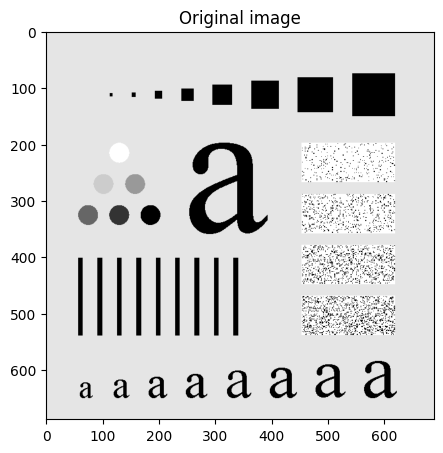

In [6]:
originalImg = cv2.imread('Characters Test Pattern 688x688.tif', cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(5,10))
plt.title('Original image')
plt.imshow(originalImg, cmap='gray')
plt.show()


### Gaussian noisy image created

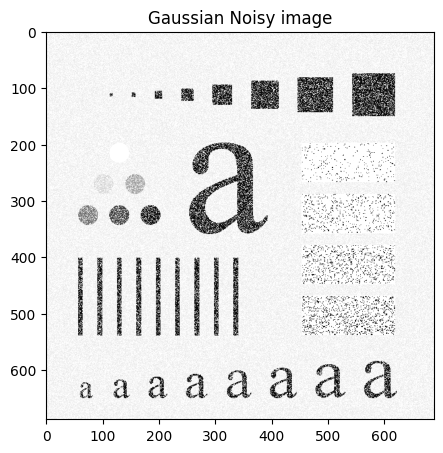

In [14]:
gaussian_noise = np.random.normal(7, 13, originalImg.shape).astype(np.uint8)
noisy_image = cv2.add(originalImg, gaussian_noise)

plt.figure(figsize=(5,10))
plt.title('Gaussian Noisy image')
plt.imshow(noisy_image, cmap='gray')
plt.show()

### Applying FFT on original image

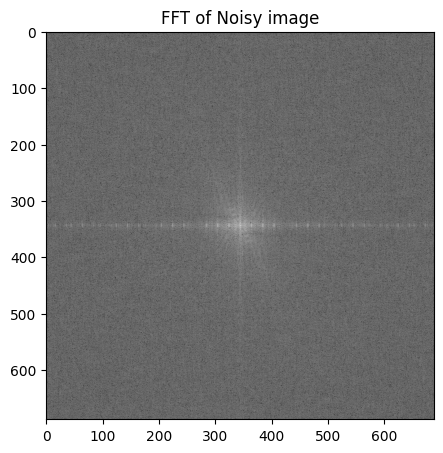

In [18]:
noisy_image_fft = np.fft.ifftshift(np.fft.fft2(noisy_image))

plt.figure(figsize=(5,10))
plt.title('FFT of Noisy image')
plt.imshow(np.log(np.abs(noisy_image_fft)), cmap='gray')
plt.show()                            

### Applying Butterworth low pass ilter 

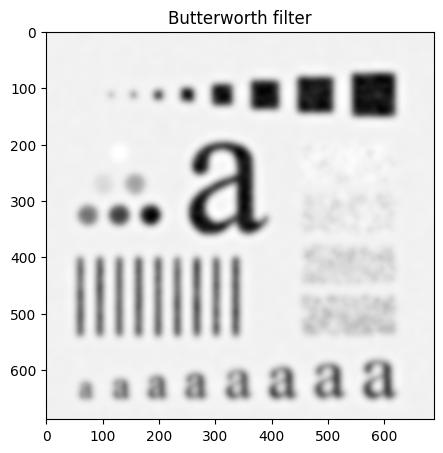

In [23]:
order = 2
radius = 25
filtered_image = butterworth_filter(noisy_image_fft, order, radius)

plt.figure(figsize=(5,10))
plt.title('Butterworth filter')
plt.imshow(filtered_image, cmap='gray')
plt.show()                            

### Applying Gaussian low pass ilter 

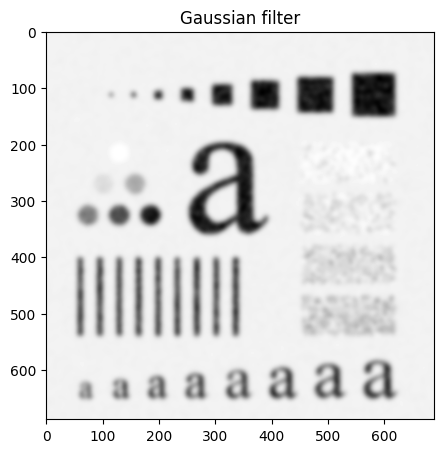

In [28]:
radius = 25
filtered_image = gaussian_filter(noisy_image_fft, radius)

plt.figure(figsize=(5,10))
plt.title('Gaussian filter')
plt.imshow(filtered_image, cmap='gray')
plt.show()                            